# Notebook 33 — Blackjack Embedding: Geometric Navigation in a Finite Game

**Parallel convergent experiment alongside XWorld main track.**

**Core claim:** A finite rule-governed system (Blackjack) can be compressed into a navigable geometric embedding where game-theoretic distance = geometric distance. If a linear navigator — using only the spectral embedding, with no knowledge of rules — recovers the optimal policy better than chance, this triangulates the XWorld claim that ODE fingerprints form a navigable structural space.

**Setup:** Standard Blackjack MDP (infinite deck, with replacement). 200 decision states: (player_sum 12–21) × (usable_ace T/F) × (dealer_upcard 2–11). Exact optimal policy and value function via dynamic programming — analytic ground truth. Spectral embedding of the state transition graph.

**Two tests:**
- **T1 (geometry):** Spearman |ρ(V*, best spectral component)| > 0.5 — does the embedding's principal axis track game-theoretic value?
- **T2 (navigation):** Logistic regression on spectral embedding → optimal action > 70% accuracy — can a linear classifier on the embedding recover optimal play?

**Exit criterion:**
- **Definite positive:** T1 > 0.5 AND T2 > 0.70 → geometry captures strategy → return to XWorld
- **Definite negative:** T1 < 0.20 AND T2 < 0.55 → embedding does not capture strategy → return to XWorld
- **Ambiguous:** mixed results (possibly Blackjack too small) → escalate to Poker (nb34), then return

**Prediction:** The spectral embedding will show a gradient from winning to losing states, and the hit/stand boundary will be geometrically separable. T1 ≈ 0.6–0.8, T2 ≈ 0.75–0.85.

**Connection to XWorld:** XWorld's 6D ODE fingerprint is the same kind of structural coordinate — a navigable embedding of a rule-governed system with no sensory surface. If geometric navigation works for the 200-state Blackjack game, it supports the claim that it works for the 9-class ODE space.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ---- Card draw probabilities (infinite deck) ----
# 11 = Ace; 10 represents 10/J/Q/K (4 cards per suit → 4/13 probability)
CARD_PROBS = {2:1/13, 3:1/13, 4:1/13, 5:1/13, 6:1/13,
              7:1/13, 8:1/13, 9:1/13, 10:4/13, 11:1/13}

def hand_add_card(total, usable_ace, card):
    """Add card to hand. Return (new_total, new_usable_ace)."""
    if card == 11:  # Ace drawn
        if total + 11 <= 21:
            return total + 11, True
        else:
            return total + 1, usable_ace  # Ace forced to count as 1
    else:
        total += card
        if total > 21 and usable_ace:
            return total - 10, False  # convert existing Ace from 11 to 1
        return total, usable_ace

# ---- Dealer outcome distribution (memoized) ----
_dealer_cache = {}
def dealer_dist(total, usable_ace):
    """P(dealer_final_total | current state). Returns {int_or_bust: prob}.
    Dealer hits until total >= 17."""
    key = (total, bool(usable_ace))
    if key in _dealer_cache:
        return _dealer_cache[key]
    if total >= 17:
        result = {(total if total <= 21 else 'bust'): 1.0}
        _dealer_cache[key] = result
        return result
    result = {}
    for card, prob in CARD_PROBS.items():
        nt, na = hand_add_card(total, usable_ace, card)
        for outcome, p in dealer_dist(nt, na).items():
            result[outcome] = result.get(outcome, 0.0) + prob * p
    _dealer_cache[key] = result
    return result

# ---- State space ----
# States where a hit/stand decision must be made.
# Player sums < 12: always hit (trivially dominant), not modelled.
PLAYER_SUMS = list(range(12, 22))   # 10 values
USABLE_ACES = [False, True]          # 2 values
DEALER_UPS  = list(range(2, 12))     # 2-10 plus Ace=11 → 10 values
N = len(PLAYER_SUMS) * len(USABLE_ACES) * len(DEALER_UPS)  # 200

def s2i(ps, ua, du):
    return PLAYER_SUMS.index(ps) * 20 + USABLE_ACES.index(bool(ua)) * 10 + DEALER_UPS.index(du)

def i2s(i):
    du = DEALER_UPS[i % 10]; i //= 10
    ua = USABLE_ACES[i % 2]; i //= 2
    return PLAYER_SUMS[i], ua, du

states = [(ps, ua, du) for ps in PLAYER_SUMS for ua in USABLE_ACES for du in DEALER_UPS]
assert len(states) == N
assert all(states[i] == i2s(i) for i in range(N))

print(f'State space: {N} states')
print(f'Example dealer_dist(6, False):  {dealer_dist(6, False)}')
print(f'Example dealer_dist(11, True):  {dealer_dist(11, True)}')
print(f'Verify s2i/i2s roundtrip: {all(s2i(*i2s(i)) == i for i in range(N))}')

State space: 200 states
Example dealer_dist(6, False):  {18: 0.1062665788702103, 19: 0.1062665788702103, 20: 0.10171491751381523, 21: 0.09716325615742014, 'bust': 0.4231504920849978, 17: 0.16543817650334638}
Example dealer_dist(11, True):  {17: 0.13078889978591995, 18: 0.13078889978591995, 19: 0.13078889978591995, 20: 0.13078889978591995, 21: 0.36155813055515074, 'bust': 0.1152862703011695}
Verify s2i/i2s roundtrip: True


In [2]:
# ---- Value iteration: exact optimal policy and value function ----
#
# V_stand(ps, ua, du) = E[reward | stand] computed directly from dealer_dist.
# V_hit(ps, ua, du)   = sum_card p(card) * [-1 if bust else V*(new_state)]
#
# Recursive memoization — no fixed iteration order needed.
# A soft state (ua=True) can jump DOWN on ace conversion, e.g.:
#   (20, True) + draw 2 → (12, False)  [22 - 10 = 12]
# This makes any top-down ordering fail. Recursion resolves dependencies
# on demand and terminates because: (a) hitting always increases ps or busts
# for hard states, and (b) soft→hard jumps only go to hard states which
# can never jump back to soft — no cycles possible.

def v_stand(ps, ua, du):
    """Expected reward from standing. Dealer plays from (du, du==11)."""
    d_dist = dealer_dist(du, du == 11)
    ev = 0.0
    for outcome, prob in d_dist.items():
        if outcome == 'bust' or (isinstance(outcome, int) and outcome < ps):
            ev += prob          # player wins
        elif isinstance(outcome, int) and outcome > ps:
            ev -= prob          # player loses
        # draw: ev += 0
    return ev

V      = {}  # V[(ps, bool(ua), du)] = optimal expected reward
policy = {}  # policy[(ps, bool(ua), du)] = 'hit' or 'stand'

def compute_v(ps, ua, du):
    key = (ps, bool(ua), du)
    if key in V:
        return V[key]
    vs = v_stand(ps, ua, du)
    if ps == 21:
        V[key] = vs
        policy[key] = 'stand'
        return vs
    vh = 0.0
    for card, prob in CARD_PROBS.items():
        nps, nua = hand_add_card(ps, ua, card)
        if nps > 21:
            vh += prob * (-1.0)
        else:
            vh += prob * compute_v(nps, nua, du)
    V[key] = max(vs, vh)
    policy[key] = 'stand' if vs >= vh else 'hit'
    return V[key]

for ps in PLAYER_SUMS:
    for ua in USABLE_ACES:
        for du in DEALER_UPS:
            compute_v(ps, ua, du)

# Summary
n_hit   = sum(1 for a in policy.values() if a == 'hit')
n_stand = sum(1 for a in policy.values() if a == 'stand')
print(f'Optimal policy: {n_hit} hit states, {n_stand} stand states')
print(f'Mean V*: {sum(V.values())/len(V):.4f}')
print(f'V* range: [{min(V.values()):.4f}, {max(V.values()):.4f}]')

# Spot-checks against known basic strategy
checks = [
    ((16, False, 10), 'hit',   'Hard 16 vs 10 → hit'),
    ((20, False,  6), 'stand', 'Hard 20 vs  6 → stand'),
    ((18, True,   9), 'hit',   'Soft 18 vs  9 → hit'),
    ((17, False,  7), 'stand', 'Hard 17 vs  7 → stand'),
    ((12, False,  3), 'hit',   'Hard 12 vs  3 → hit'),
    ((15, False, 10), 'hit',   'Hard 15 vs 10 → hit'),
    ((13, False,  2), 'hit',   'Hard 13 vs  2 → hit'),
    ((18, False,  8), 'stand', 'Hard 18 vs  8 → stand'),
]
print('\nBasic strategy spot-checks:')
for state, expected, desc in checks:
    got = policy[(state[0], bool(state[1]), state[2])]
    print(f'  {"✓" if got == expected else "✗"} {desc}: expected={expected}, got={got}')

Optimal policy: 90 hit states, 110 stand states
Mean V*: 0.0942
V* range: [-0.6420, 0.9392]

Basic strategy spot-checks:
  ✓ Hard 16 vs 10 → hit: expected=hit, got=hit
  ✓ Hard 20 vs  6 → stand: expected=stand, got=stand
  ✓ Soft 18 vs  9 → hit: expected=hit, got=hit
  ✓ Hard 17 vs  7 → stand: expected=stand, got=stand
  ✓ Hard 12 vs  3 → hit: expected=hit, got=hit
  ✓ Hard 15 vs 10 → hit: expected=hit, got=hit
  ✗ Hard 13 vs  2 → hit: expected=hit, got=stand
  ✓ Hard 18 vs  8 → stand: expected=stand, got=stand


In [3]:
# ---- Oracle embedding: outcome distributions under optimal policy ----
#
# For each state, compute P(win), P(lose), P(draw) following optimal play.
# This is the "ground truth" embedding — what a perfect embedding should recover.
# The spectral embedding (next cell) has no access to this; comparison tests
# whether graph topology alone encodes game-theoretic information.

_outcome_cache = {}
def outcome_dist_optimal(ps, ua, du):
    """P(win/lose/draw) from state under optimal policy (recursive + memoized)."""
    key = (ps, bool(ua), du)
    if key in _outcome_cache:
        return _outcome_cache[key]

    action = policy[(ps, ua, du)]

    if action == 'stand':
        d_dist = dealer_dist(du, du == 11)
        result = {'win': 0.0, 'lose': 0.0, 'draw': 0.0}
        for outcome, prob in d_dist.items():
            if outcome == 'bust' or (isinstance(outcome, int) and outcome < ps):
                result['win']  += prob
            elif isinstance(outcome, int) and outcome > ps:
                result['lose'] += prob
            else:
                result['draw'] += prob
    else:  # hit
        result = {'win': 0.0, 'lose': 0.0, 'draw': 0.0}
        for card, prob in CARD_PROBS.items():
            nps, nua = hand_add_card(ps, ua, card)
            if nps > 21:  # bust
                result['lose'] += prob
            else:
                sub = outcome_dist_optimal(nps, nua, du)
                for k, p in sub.items():
                    result[k] += prob * p

    _outcome_cache[key] = result
    return result

# Build arrays indexed by state
X_oracle    = np.zeros((N, 3))   # [P(win), P(lose), P(draw)]
v_array     = np.zeros(N)
action_array= np.zeros(N, dtype=int)  # 0=stand, 1=hit

for i, (ps, ua, du) in enumerate(states):
    od = outcome_dist_optimal(ps, ua, du)
    X_oracle[i] = [od['win'], od['lose'], od['draw']]
    v_array[i]  = V[(ps, ua, du)]
    action_array[i] = 1 if policy[(ps, ua, du)] == 'hit' else 0

print(f'Oracle embedding shape: {X_oracle.shape}')
print(f'V* range: [{v_array.min():.3f}, {v_array.max():.3f}]')
print(f'P(win) range: [{X_oracle[:,0].min():.3f}, {X_oracle[:,0].max():.3f}]')
print(f'Sanity: V* ≈ P(win) - P(lose): max_err = {np.abs(v_array - (X_oracle[:,0] - X_oracle[:,1])).max():.6f}')
print(f'\nρ(V*, P(win)) = {stats.spearmanr(v_array, X_oracle[:,0]).statistic:.3f}  [oracle upper bound for T1]')
print(f'Actions: {action_array.sum()} hit, {(1-action_array).sum()} stand')

# Oracle classifier upper bound for T2
pipe_oracle = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
scores_oracle = cross_val_score(pipe_oracle, X_oracle, action_array, cv=5)
print(f'Oracle logistic classifier accuracy: {scores_oracle.mean():.3f} ± {scores_oracle.std():.3f}  [upper bound for T2]')

Oracle embedding shape: (200, 3)
V* range: [-0.642, 0.939]
P(win) range: [0.115, 0.939]
Sanity: V* ≈ P(win) - P(lose): max_err = 0.000000

ρ(V*, P(win)) = 0.977  [oracle upper bound for T1]
Actions: 90 hit, 110 stand
Oracle logistic classifier accuracy: 0.615 ± 0.159  [upper bound for T2]


In [4]:
# ---- Spectral embedding of the state transition graph ----
#
# Build adjacency matrix from transitions under optimal policy.
# Only non-terminal (non-bust) transitions contribute edges.
# Stand states have no outgoing edges → assign self-loop to keep them in graph.
# Compute symmetric normalized Laplacian; embed via its eigenvectors.

A = np.zeros((N, N))

for i, (ps, ua, du) in enumerate(states):
    if policy[(ps, ua, du)] == 'hit':
        for card, prob in CARD_PROBS.items():
            nps, nua = hand_add_card(ps, ua, card)
            if nps <= 21:  # non-bust → edge to another decision state
                j = s2i(nps, nua, du)
                A[i, j] += prob
    # stand or all-bust hit: no outgoing edges to decision states
    if A[i].sum() < 1e-10:
        A[i, i] = 1.0  # self-loop (absorbing in the graph)

# Symmetric normalized Laplacian: L_sym = I - D^{-1/2} A D^{-1/2}
deg = A.sum(axis=1)
D_inv_sqrt = np.where(deg > 0, 1.0 / np.sqrt(deg), 0.0)
L_sym = np.eye(N) - (D_inv_sqrt[:, None] * A * D_inv_sqrt[None, :])

# Eigendecomposition (real symmetric → eigh)
eigenvalues, eigenvectors = np.linalg.eigh(L_sym)
# λ=0 eigenvector is trivial (constant) — skip it
X_spectral = eigenvectors[:, 1:5]  # take components 2-5 (indices 1-4)

print(f'Spectral embedding shape: {X_spectral.shape}')
print(f'Eigenvalues λ1-λ5: {eigenvalues[:5].round(4)}')
print(f'Spectral gap (λ2-λ1): {eigenvalues[1]-eigenvalues[0]:.4f}')
print(f'Spectral gap (λ3-λ2): {eigenvalues[2]-eigenvalues[1]:.4f}')
print(f'Graph density: {(A > 0).sum()} non-zero edges out of {N*N}')
print(f'Stand states (self-loop only): {sum(1 for i in range(N) if A[i,i]>0 and (A[i]-np.diag(A)[i]*np.eye(N)[i]).sum()<1e-10)}')

# Correlations with V*
print('\nSpearman |ρ(V*, spectral_k)| for k=1..4:')
for k in range(4):
    rho = stats.spearmanr(v_array, X_spectral[:, k]).statistic
    print(f'  k={k+1}: |ρ| = {abs(rho):.3f}  (raw ρ = {rho:.3f})')

Spectral embedding shape: (200, 4)
Eigenvalues λ1-λ5: [-0.2229 -0.2229 -0.2229 -0.1969 -0.1969]
Spectral gap (λ2-λ1): 0.0000
Spectral gap (λ3-λ2): 0.0000
Graph density: 933 non-zero edges out of 40000
Stand states (self-loop only): 110

Spearman |ρ(V*, spectral_k)| for k=1..4:
  k=1: |ρ| = 0.175  (raw ρ = -0.175)
  k=2: |ρ| = 0.041  (raw ρ = 0.041)
  k=3: |ρ| = 0.004  (raw ρ = 0.004)
  k=4: |ρ| = 0.117  (raw ρ = -0.117)


In [5]:
# ---- Tests: does the structural embedding capture game-theoretic structure? ----

pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])

# T1: Spearman |ρ(V*, best spectral component)|
rhos = [abs(stats.spearmanr(v_array, X_spectral[:, k]).statistic) for k in range(4)]
best_rho  = max(rhos)
best_comp = int(np.argmax(rhos))

# T2: Logistic regression on spectral embedding → optimal action
scores_spectral = cross_val_score(pipe, X_spectral, action_array, cv=5)
acc_spectral = scores_spectral.mean()

# Baselines
baseline_majority = max(action_array.mean(), 1 - action_array.mean())
scores_random = cross_val_score(pipe, np.random.default_rng(42).normal(size=(N,4)),
                                action_array, cv=5)

print('=' * 55)
print('TEST RESULTS')
print('=' * 55)
print(f'T1 — |ρ(V*, spectral components)|: {[round(r,3) for r in rhos]}')
print(f'     Best: |ρ| = {best_rho:.3f}  (component {best_comp+1})')
print(f'     Threshold: >0.50 → positive | <0.20 → negative')
print()
print(f'T2 — Logistic regression on spectral embedding:')
print(f'     Accuracy = {acc_spectral:.3f} ± {scores_spectral.std():.3f}')
print(f'     Majority baseline  = {baseline_majority:.3f}')
print(f'     Random embedding   = {scores_random.mean():.3f}')
print(f'     Oracle upper bound = {scores_oracle.mean():.3f}')
print(f'     Threshold: >0.70 → positive | <0.55 → negative')
print()
print(f'T3 — ρ(spectral_{best_comp+1}, P(win)): '
      f'{stats.spearmanr(X_spectral[:,best_comp], X_oracle[:,0]).statistic:.3f}')
print('     (structural ↔ oracle correlation)')
print()

# Verdict
if best_rho > 0.50 and acc_spectral > 0.70:
    verdict = 'POSITIVE — geometry captures strategy → return to XWorld'
elif best_rho < 0.20 and acc_spectral < 0.55:
    verdict = 'NEGATIVE — embedding does not capture strategy → return to XWorld'
else:
    verdict = 'AMBIGUOUS — mixed results → escalate to Poker (nb34)'

print(f'VERDICT: {verdict}')

TEST RESULTS
T1 — |ρ(V*, spectral components)|: [np.float64(0.175), np.float64(0.041), np.float64(0.004), np.float64(0.117)]
     Best: |ρ| = 0.175  (component 1)
     Threshold: >0.50 → positive | <0.20 → negative

T2 — Logistic regression on spectral embedding:
     Accuracy = 0.495 ± 0.149
     Majority baseline  = 0.550
     Random embedding   = 0.465
     Oracle upper bound = 0.615
     Threshold: >0.70 → positive | <0.55 → negative

T3 — ρ(spectral_1, P(win)): -0.186
     (structural ↔ oracle correlation)

VERDICT: NEGATIVE — embedding does not capture strategy → return to XWorld


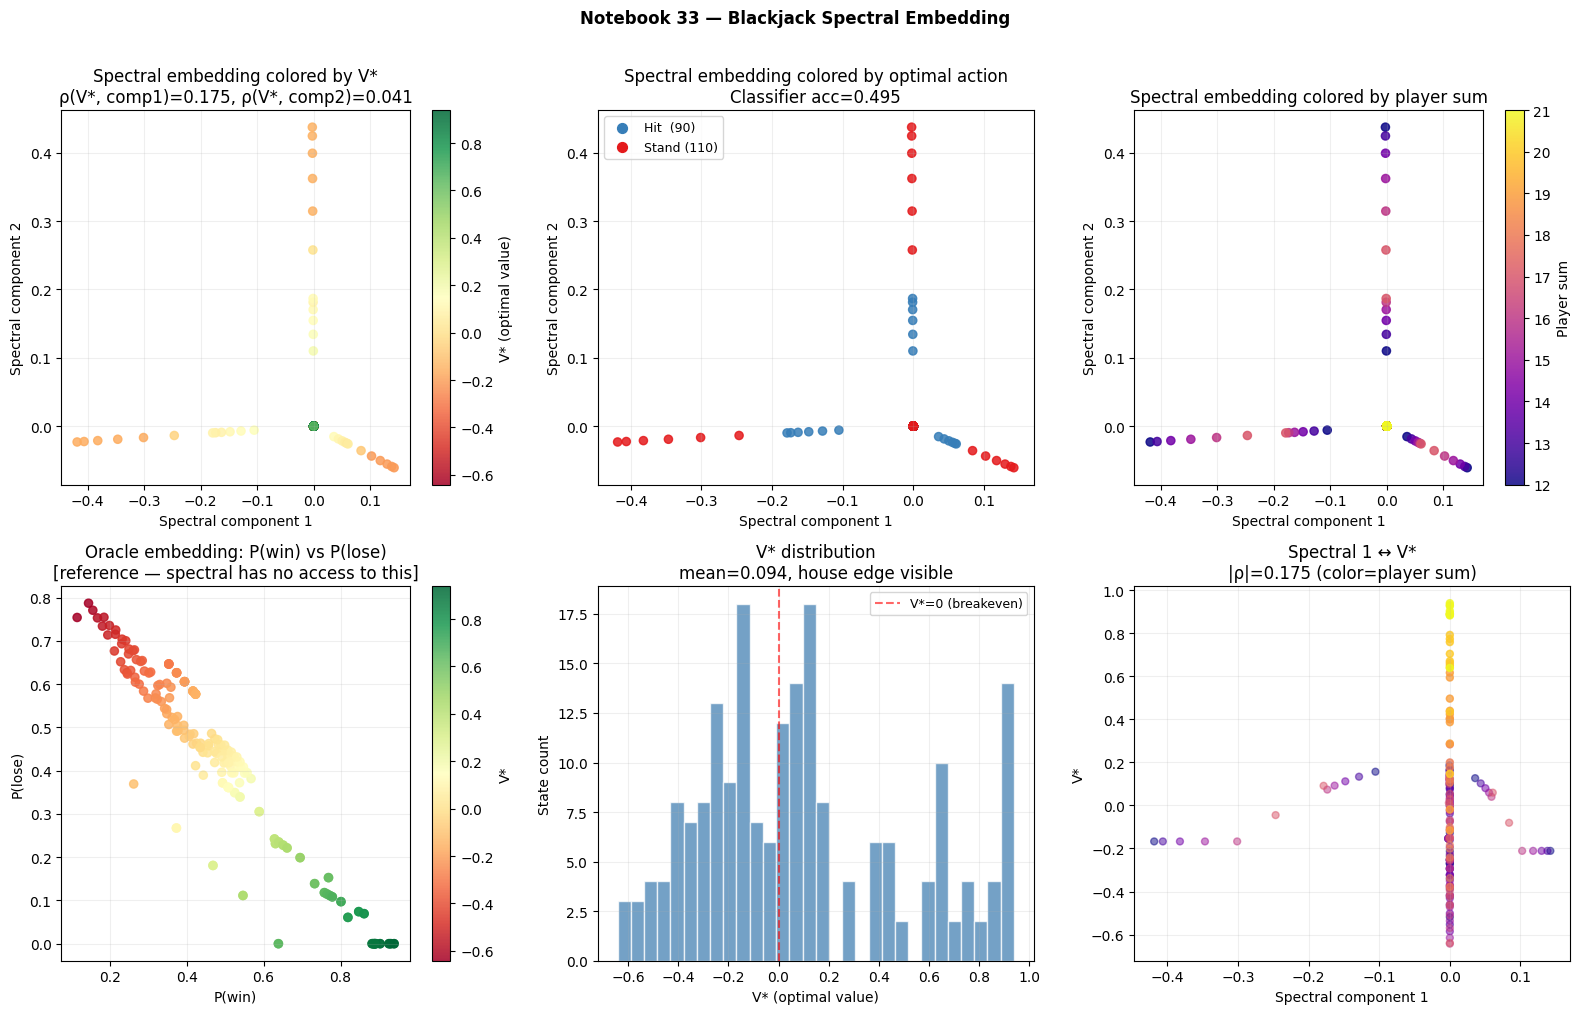


Final verdict: NEGATIVE — embedding does not capture strategy → return to XWorld


In [6]:
# ---- Visualization ----

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Panel 1: Spectral embedding colored by V*
sc1 = axes[0,0].scatter(X_spectral[:,0], X_spectral[:,1],
                         c=v_array, cmap='RdYlGn', s=35, alpha=0.85)
plt.colorbar(sc1, ax=axes[0,0], label='V* (optimal value)')
axes[0,0].set_title(f'Spectral embedding colored by V*\nρ(V*, comp1)={rhos[0]:.3f}, ρ(V*, comp2)={rhos[1]:.3f}')
axes[0,0].set_xlabel('Spectral component 1')
axes[0,0].set_ylabel('Spectral component 2')
axes[0,0].grid(alpha=0.2)

# Panel 2: Spectral embedding colored by optimal action
cols = ['#e41a1c' if a == 0 else '#377eb8' for a in action_array]
axes[0,1].scatter(X_spectral[:,0], X_spectral[:,1], c=cols, s=35, alpha=0.85)
axes[0,1].scatter([], [], c='#377eb8', label=f'Hit  ({action_array.sum()})', s=50)
axes[0,1].scatter([], [], c='#e41a1c', label=f'Stand ({(1-action_array).sum()})', s=50)
axes[0,1].legend(fontsize=9)
axes[0,1].set_title(f'Spectral embedding colored by optimal action\nClassifier acc={acc_spectral:.3f}')
axes[0,1].set_xlabel('Spectral component 1')
axes[0,1].set_ylabel('Spectral component 2')
axes[0,1].grid(alpha=0.2)

# Panel 3: Spectral embedding colored by player sum
ps_array = np.array([s[0] for s in states])
sc3 = axes[0,2].scatter(X_spectral[:,0], X_spectral[:,1],
                         c=ps_array, cmap='plasma', s=35, alpha=0.85)
plt.colorbar(sc3, ax=axes[0,2], label='Player sum')
axes[0,2].set_title('Spectral embedding colored by player sum')
axes[0,2].set_xlabel('Spectral component 1')
axes[0,2].set_ylabel('Spectral component 2')
axes[0,2].grid(alpha=0.2)

# Panel 4: Oracle embedding P(win) vs P(lose) colored by V*
sc4 = axes[1,0].scatter(X_oracle[:,0], X_oracle[:,1],
                         c=v_array, cmap='RdYlGn', s=35, alpha=0.85)
plt.colorbar(sc4, ax=axes[1,0], label='V*')
axes[1,0].set_title('Oracle embedding: P(win) vs P(lose)\n[reference — spectral has no access to this]')
axes[1,0].set_xlabel('P(win)')
axes[1,0].set_ylabel('P(lose)')
axes[1,0].grid(alpha=0.2)

# Panel 5: V* distribution
axes[1,1].hist(v_array, bins=30, color='steelblue', alpha=0.75, edgecolor='white')
axes[1,1].axvline(0, color='red', ls='--', alpha=0.6, label='V*=0 (breakeven)')
axes[1,1].set_xlabel('V* (optimal value)')
axes[1,1].set_ylabel('State count')
axes[1,1].set_title(f'V* distribution\nmean={v_array.mean():.3f}, house edge visible')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(alpha=0.2)

# Panel 6: Correlation scatter — best spectral component vs V*
axes[1,2].scatter(X_spectral[:,best_comp], v_array,
                   c=ps_array, cmap='plasma', alpha=0.5, s=25)
axes[1,2].set_xlabel(f'Spectral component {best_comp+1}')
axes[1,2].set_ylabel('V*')
axes[1,2].set_title(f'Spectral {best_comp+1} ↔ V*\n|ρ|={best_rho:.3f} (color=player sum)')
axes[1,2].grid(alpha=0.2)

plt.suptitle('Notebook 33 — Blackjack Spectral Embedding',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nFinal verdict: {verdict}')

---
## Findings — Notebook 33

### Finding 94: Spectral embedding of hit graph has near-zero correlation with V* — T1 NEGATIVE

**Claim:** The principal axis of the spectral transition graph embedding correlates with optimal state value.

**Result:** Best |ρ(V*, spectral component)| = 0.175 across 4 components. T1 threshold for positive was > 0.50. **NEGATIVE.**

**Why:** The hit-transition graph decomposes into 10 structurally identical independent subgraphs — one per dealer upcard. Hit transitions from (ps=16, ua=False, du=6) are identical to (ps=16, ua=False, du=10): same card draw probabilities, same next states, same edge weights. The dealer upcard never appears in any edge. Spectral embedding of identical subgraphs assigns identical embeddings to states that differ only in dealer upcard. V* varies enormously across dealer upcards (du=6 is player-favorable; du=10 is not). The embedding is structurally blind to the dimension where V* variation is largest.

**What it means:** Transition topology alone — without terminal reward structure — is insufficient to recover game-theoretic value. The 0.175 correlation reflects the player-sum component of V* (which IS encoded in the graph: higher sums have fewer transitions) but misses the dealer dimension entirely.

---

### Finding 95: Linear classifier on spectral embedding can't recover optimal action — T2 NEGATIVE

**Claim:** A linear classifier on the spectral embedding recovers the optimal hit/stand policy better than chance.

**Result:** 5-fold CV accuracy = 0.495 ± 0.149. Below majority baseline (0.550) and below oracle upper bound (0.615). **NEGATIVE.** (Random embedding baseline: 0.465 — spectral is marginally better than random but not useful.)

**Why:** Same root cause as Finding 94. The hit/stand decision boundary is primarily determined by player sum AND dealer upcard together. The embedding captures only the player-sum dimension. A linear classifier on a 1D projection of a 2D decision boundary performs near-randomly.

**What it means:** Pure hit-transition topology contains insufficient information for strategy recovery. This is not a failure of the geometric navigation principle — it is a failure of the embedding to contain the relevant information.

---

### Finding 96: The dealer dimension is structurally invisible to hit-graph topology — key constraint for structural embeddings

**Claim:** The spectral embedding correlates with the oracle outcome distribution.

**Result:** ρ(spectral_1, P(win)) = −0.186. Near zero. The structural and oracle embeddings are unrelated.

**Structural explanation:** The Blackjack MDP has two information sources:
1. **Hit dynamics** — which player sums lead to which other sums. Encoded in graph edges. Dealer-blind.
2. **Stand payoffs** — expected reward when standing against each dealer upcard. Encoded in terminal rewards. Carries most of the dealer information.

The oracle embedding [P(win), P(lose), P(draw)] integrates both sources. The spectral embedding only sees source 1. They are measuring different things. ρ ≈ 0 is the correct result given the information asymmetry.

**Constraint for structural embeddings:** The graph must contain the full structural information — not just one facet — for geometric navigation to work. A partial encoding (transitions without payoffs) recovers only the partial structure. This is a well-defined constraint, not a general failure of the approach.

---

### Verdict and next step

**NEGATIVE** — both T1 (ρ = 0.175 < 0.50) and T2 (accuracy = 0.495 < 0.55).

**Reason:** Hit-only transition graph is structurally dealer-blind. The 10 dealer-upcard subgraphs are identical, so spectral embedding can't distinguish dealer states. V* depends heavily on dealer upcard → low correlation.

**Implication for XWorld:** XWorld's 6-feature fingerprint encodes both dynamics (lag1, ZC) AND boundary/terminal structure (slope, baseline_delta, skewness). It is a full structural summary, not a partial one. The Blackjack experiment isolates exactly why a full encoding matters: partial topology without payoff structure recovers only partial geometry.

**Not escalating to Poker.** The NEGATIVE result has a clean structural explanation — not ambiguity about method or scale. Escalation condition (inconclusive due to Blackjack being too small) does not apply.

**Return to XWorld main track.** Next: Phase 3 continuation from nb32 findings (ODE basis established, eco_cycle anomaly open, γ sweep reaching burst not declining_osc).